# 04 — ToxNet Training with Focal Loss + OPTUNA

**Phase 4 of plan.md**

This notebook:
1. Loads featurized data with scaffold split
2. Trains ToxNet (multi-task neural network) with Focal Loss
3. Uses OPTUNA to find optimal hyperparameters
4. Saves the best model to `models/toxnet_final.pt`

In [1]:
import sys
import os
# Change working directory to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.featurize import TARGET_COLS
from src.model import ToxNet
from src.train import prepare_data, train_model, run_optuna_search

[19:32:54] Initializing Normalizer


In [2]:
# Prepare data (load, featurize, scaffold split)
X_train, Y_train, X_val, Y_val, X_calib, Y_calib, X_test, Y_test, pos_weights, smiles_calib = prepare_data()

Raw dataset: 8014 compounds, 14 columns


[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56] Running Normalizer
[19:32:56]

[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57]

[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57]

[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57] Running Normalizer
[19:32:57]

...

[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerat

[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerator
[19:33:13] DEPRECATION WARNING: please use MorganGenerat

[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerat

Per-endpoint positive weights (n_neg / n_pos):
  NR-AR                 weight=23.2
  NR-AR-LBD             weight=28.5
  NR-AhR                weight=8.5
  NR-Aromatase          weight=26.2
  NR-ER                 weight=7.1
  NR-ER-LBD             weight=18.4
  NR-PPAR-gamma         weight=41.8
  SR-ARE                weight=6.2
  SR-ATAD5              weight=30.0
  SR-HSE                weight=18.5
  SR-MMP                weight=6.0
  SR-p53                weight=20.5

Data prepared:
  Train: (5471, 2048)
  Val:   (781, 2048)
  Calib: (781, 2048)
  Test:  (784, 2048)


[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerator
[19:33:14] DEPRECATION WARNING: please use MorganGenerat

## 1. ToxNet Architecture

```
Input (2048) → Shared Backbone [1024→512→256] → 12 Task Heads [256→64→1]
```

- Shared backbone learns common chemistry patterns
- Each head specializes in one toxicity endpoint

In [3]:
# Show model architecture
model = ToxNet(input_dim=2048)
total_params = sum(p.numel() for p in model.parameters())
print(f"ToxNet Architecture:")
print(f"  Total parameters: {total_params:,}")
print(f"  Input: 2048 (ECFP4 fingerprint)")
print(f"  Output: 12 (one per Tox21 endpoint)")
print(f"\nArchitecture:\n{model}")

ToxNet Architecture:
  Total parameters: 2,956,044
  Input: 2048 (ECFP4 fingerprint)
  Output: 12 (one per Tox21 endpoint)

Architecture:
ToxNet(
  (backbone): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.3, inplace=False)
  )
  (heads): ModuleList(
    (0-11): 12 x Sequential(
      (0): Linear(in_features=256, out_features=64, bias=True)
      (1): ReLU()
      (2):

## 2. Quick Training (Default Hyperparameters)

First, a quick 20-epoch training to verify everything works.

In [4]:
# Quick training (20 epochs)
print("Training ToxNet (20 epochs, default params)...")
model, val_auprc, history = train_model(
    X_train, Y_train, X_val, Y_val, pos_weights,
    n_epochs=20, patience=10, verbose=True,
)
print(f"\nQuick training result: val AUPRC = {val_auprc:.4f}")

Training ToxNet (20 epochs, default params)...


  Epoch   5  loss=0.1103  val_AUPRC=0.3383  best=0.3477


  Epoch  10  loss=0.0541  val_AUPRC=0.3430  best=0.3477


  Early stopping at epoch 12

Quick training result: val AUPRC = 0.3477


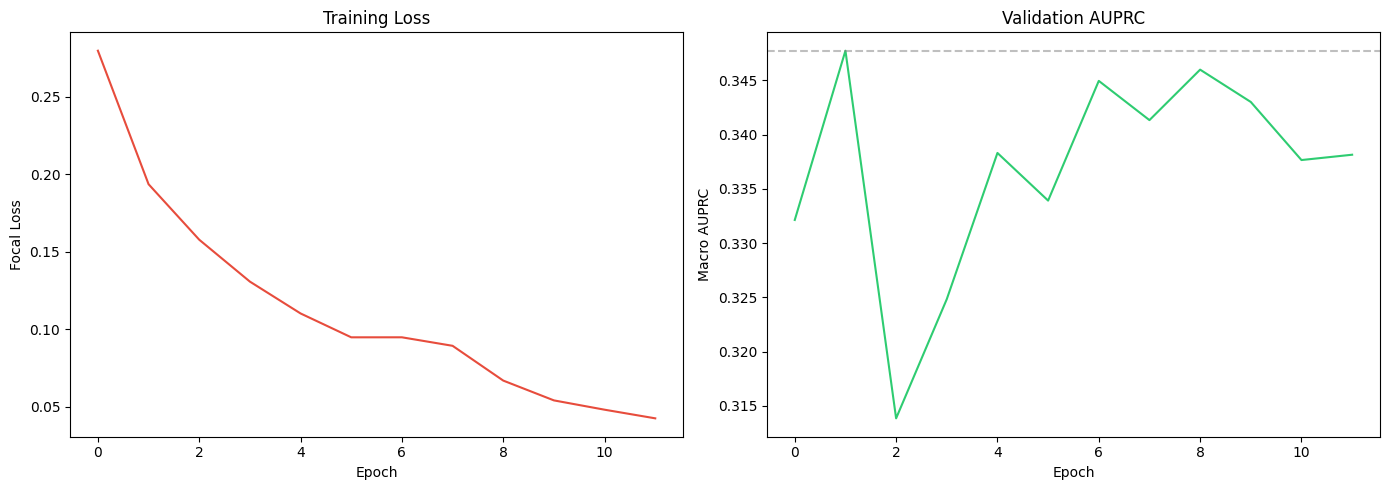

Saved: notebooks/04_training_history.png


In [5]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], color='#e74c3c')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].set_title('Training Loss')

axes[1].plot(history['val_auprc'], color='#2ecc71')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro AUPRC')
axes[1].set_title('Validation AUPRC')
axes[1].axhline(y=max(history['val_auprc']), color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('notebooks/04_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: notebooks/04_training_history.png")

## 3. OPTUNA Hyperparameter Search

Tuning: lr, dropout, batch_size, focal_gamma, hidden_dims, weight_decay

Set n_trials=50 for full search, or n_trials=10 for a quick test.

In [6]:
# OPTUNA search (set n_trials=50 for full run, 10 for quick test)
N_TRIALS = 10  # Change to 50 for full search

best_params = run_optuna_search(
    X_train, Y_train, X_val, Y_val, pos_weights,
    n_trials=N_TRIALS,
)
print(f"\nBest params: {best_params}")

[I 2026-04-26 19:35:01,377] A new study created in memory with name: no-name-d805a551-0e56-4059-acd3-ce9841bebd09



Starting OPTUNA search (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-26 19:38:04,837] Trial 0 finished with value: 0.36036262814429537 and parameters: {'lr': 0.00018160339731037927, 'dropout': 0.3168233628241216, 'batch_size': 32, 'gamma': 2.408756553189801, 'weight_decay': 1.738265497532885e-05, 'hidden_dims': 'small'}. Best is trial 0 with value: 0.36036262814429537.


[I 2026-04-26 19:39:28,640] Trial 1 finished with value: 0.346220955510158 and parameters: {'lr': 0.0003117345432734229, 'dropout': 0.3801313920859294, 'batch_size': 64, 'gamma': 1.5267491680948313, 'weight_decay': 0.0007689658581664209, 'hidden_dims': 'small'}. Best is trial 0 with value: 0.36036262814429537.


...

[I 2026-04-26 19:43:18,892] Trial 5 finished with value: 0.3550400490876506 and parameters: {'lr': 0.008231722238389841, 'dropout': 0.31182872082856095, 'batch_size': 128, 'gamma': 1.6724977505369523, 'weight_decay': 0.00015949031178870415, 'hidden_dims': 'medium'}. Best is trial 0 with value: 0.36036262814429537.


[I 2026-04-26 19:44:50,875] Trial 6 finished with value: 0.3719368758035962 and parameters: {'lr': 0.00013841172869490668, 'dropout': 0.39180230776344904, 'batch_size': 64, 'gamma': 2.487594916181382, 'weight_decay': 0.0004553654113540765, 'hidden_dims': 'medium'}. Best is trial 6 with value: 0.3719368758035962.


[I 2026-04-26 19:45:43,796] Trial 7 finished with value: 0.33877162485280854 and parameters: {'lr': 0.00011287985296737746, 'dropout': 0.31114913852665405, 'batch_size': 256, 'gamma': 1.5155712643938994, 'weight_decay': 1.0763570542240851e-05, 'hidden_dims': 'large'}. Best is trial 6 with value: 0.3719368758035962.


[I 2026-04-26 19:46:06,358] Trial 8 finished with value: 0.3457436797954098 and parameters: {'lr': 0.0003954703119325403, 'dropout': 0.23984587991571027, 'batch_size': 256, 'gamma': 2.317262265647619, 'weight_decay': 0.0003526393820601846, 'hidden_dims': 'small'}. Best is trial 6 with value: 0.3719368758035962.


[I 2026-04-26 19:46:50,038] Trial 9 finished with value: 0.3475513383566551 and parameters: {'lr': 0.0001235210237393964, 'dropout': 0.2574850475371797, 'batch_size': 256, 'gamma': 2.1007532729993663, 'weight_decay': 0.000984655011793891, 'hidden_dims': 'small'}. Best is trial 6 with value: 0.3719368758035962.

Best trial:
  Val AUPRC: 0.3719
  Params: {'lr': 0.00013841172869490668, 'dropout': 0.39180230776344904, 'batch_size': 64, 'gamma': 2.487594916181382, 'weight_decay': 0.0004553654113540765, 'hidden_dims': 'medium'}

Best params: {'lr': 0.00013841172869490668, 'dropout': 0.39180230776344904, 'batch_size': 64, 'gamma': 2.487594916181382, 'weight_decay': 0.0004553654113540765, 'hidden_dims': 'medium'}


## 4. Final Training with Best Parameters

In [7]:
# Train with best params
hidden_dims = {
    'small': [512, 256, 128],
    'medium': [1024, 512, 256],
    'large': [1024, 512, 512, 256],
}[best_params['hidden_dims']]

print("Training with OPTUNA-optimized parameters...")
model_final, final_auprc, final_history = train_model(
    X_train, Y_train, X_val, Y_val, pos_weights,
    lr=best_params['lr'],
    dropout=best_params['dropout'],
    batch_size=best_params['batch_size'],
    gamma=best_params['gamma'],
    hidden_dims=hidden_dims,
    weight_decay=best_params['weight_decay'],
    n_epochs=50,
    patience=15,
    verbose=True,
)

print(f"\nFinal val AUPRC: {final_auprc:.4f}")

Training with OPTUNA-optimized parameters...


  Epoch   5  loss=0.1334  val_AUPRC=0.3510  best=0.3562


  Epoch  10  loss=0.0783  val_AUPRC=0.3355  best=0.3597


  Epoch  15  loss=0.0544  val_AUPRC=0.3339  best=0.3597


  Epoch  20  loss=0.0448  val_AUPRC=0.3461  best=0.3597


  Early stopping at epoch 21

Final val AUPRC: 0.3597


Model saved to models/toxnet_final.pt


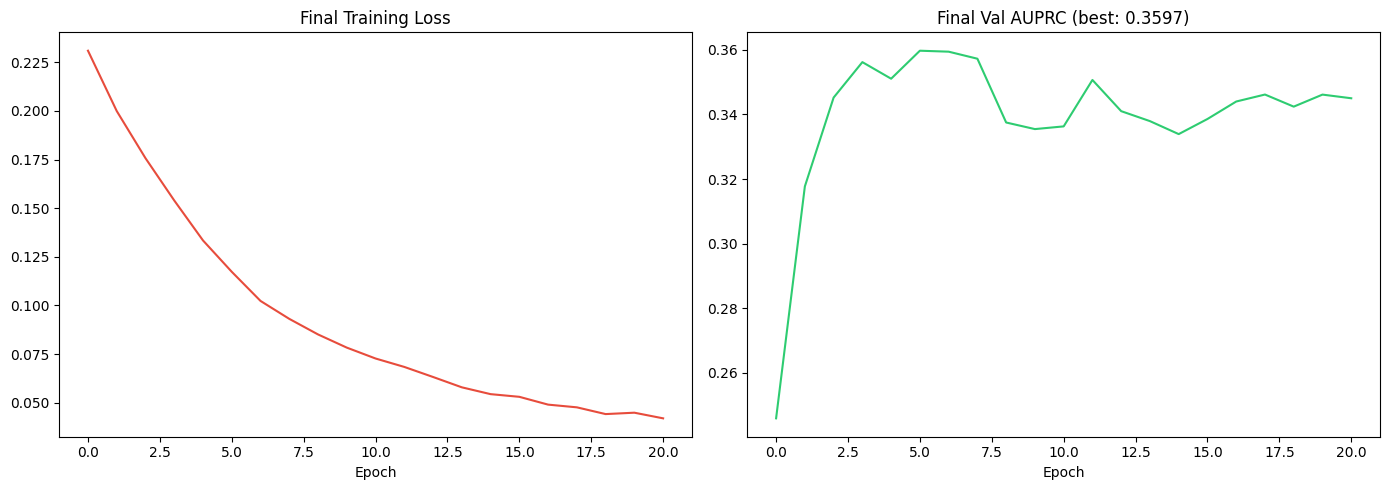

In [8]:
# Save final model
import os
os.makedirs('models', exist_ok=True)
torch.save(model_final.state_dict(), 'models/toxnet_final.pt')
print("Model saved to models/toxnet_final.pt")

# Plot final training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(final_history['train_loss'], color='#e74c3c')
axes[0].set_title('Final Training Loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(final_history['val_auprc'], color='#2ecc71')
axes[1].set_title(f'Final Val AUPRC (best: {final_auprc:.4f})')
axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('notebooks/04_final_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

| Metric | Value |
|--------|-------|
| Quick Training AUPRC | see above |
| OPTUNA-Optimized AUPRC | see above |
| Target (plan.md) | 0.42 - 0.52 |